## **Part B: Exploration of Advanced Techniques**

## **Task 1: Load the Libraries, Set File Paths & Image Size**

In [1]:
print('='*50)
print("Part B - TASK 1: Import Libraries")
print('='*50)
print()

#----Core Libraries----
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import tensorflow as tf

#----Keras: Libraries----
from keras.models import Sequential
from keras.layers import (Conv2D, Flatten, Dense, BatchNormalization, Dropout, MaxPooling2D, GlobalAveragePooling2D, Input)

#----MobileNetV2----
from keras.applications import MobileNetV2
from keras.models import Model
from keras.applications.mobilenet_v2 import preprocess_input

#----Scikit-Learn Libraries----
from sklearn.metrics import classification_report

print('='*10)
print("Libraries Loaded!")
print('='*10)

Part B - TASK 1: Import Libraries


Libraries Loaded!


In [2]:
#Set file path with a variable set name
TRAIN_DIR = './project_data/train'
VALID_DIR = './project_data/valid'
TEST_DIR = './project_data/test'

print("File paths set!")

File paths set!


In [3]:
#To extract 53 classes of the folder (Train, Valid, Test)
class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f"Found: {num_classes} classes")
print(f"First 5 classes: {class_names[:5]}")

Found: 53 classes
First 5 classes: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs']


## **Task 2: Preprocessing**

In [4]:
#Custom Load Data
def load_data(directory, class_to_idx, image_size=(96, 96)):
    X_values = []
    y_values = []

    folder_name = os.path.basename(directory)

    folders = sorted([f for f in os.listdir(directory) if not f.startswith('.')])
    
    #Header
    print('-'*50)
    print(f"Found {folder_name} - Folders: {len(folders)} class folders inside")
    print('-'*50)
    for each_folder in folders:
        sub_path = os.path.join(directory, each_folder)
        
        if not os.path.isdir(sub_path):
            continue

        label = class_to_idx[each_folder]
        print(f"Processing folders: {each_folder} -> Label: {label}")
    
        for each_image in sorted(os.listdir(sub_path)):
            if not each_image.startswith('.'):
                full_path = os.path.join(sub_path, each_image)
                
                #image editing
                image = cv2.imread(full_path)
                if image is None:
                    continue
                image = cv2.resize(image, image_size)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                
                X_values.append(image)
                y_values.append(label)
    
    
    #Footer
    print('='*50)
    print(f'{folder_name} Folder - COMPLETE -- {len(X_values)} images loaded')
    print('='*50)
    print()

    #Conversion of input into arrays            
    X_array = np.array(X_values)
    y_array = np.array(y_values)

    #Output
    return X_array, y_array

In [5]:
print('='*50)
print("Part B - TASK 2: Preprocessing")
print('='*50)
print()

#Load the Train File Directory
print('='*50)
print("Loading the Train File")
print('='*50)
print()

X_train, y_train = load_data(TRAIN_DIR, class_to_idx, image_size=(96,96))

Part B - TASK 2: Preprocessing

Loading the Train File

--------------------------------------------------
Found train - Folders: 53 class folders inside
--------------------------------------------------
Processing folders: ace of clubs -> Label: 0
Processing folders: ace of diamonds -> Label: 1
Processing folders: ace of hearts -> Label: 2
Processing folders: ace of spades -> Label: 3
Processing folders: eight of clubs -> Label: 4
Processing folders: eight of diamonds -> Label: 5
Processing folders: eight of hearts -> Label: 6
Processing folders: eight of spades -> Label: 7
Processing folders: five of clubs -> Label: 8
Processing folders: five of diamonds -> Label: 9
Processing folders: five of hearts -> Label: 10
Processing folders: five of spades -> Label: 11
Processing folders: four of clubs -> Label: 12
Processing folders: four of diamonds -> Label: 13
Processing folders: four of hearts -> Label: 14
Processing folders: four of spades -> Label: 15
Processing folders: jack of clubs

In [6]:
#Load the Valid File Directory
print('='*50)
print("Loading the Valid File")
print('='*50)
print()

X_val, y_val = load_data(VALID_DIR, class_to_idx, image_size=(96,96))

Loading the Valid File

--------------------------------------------------
Found valid - Folders: 53 class folders inside
--------------------------------------------------
Processing folders: ace of clubs -> Label: 0
Processing folders: ace of diamonds -> Label: 1
Processing folders: ace of hearts -> Label: 2
Processing folders: ace of spades -> Label: 3
Processing folders: eight of clubs -> Label: 4
Processing folders: eight of diamonds -> Label: 5
Processing folders: eight of hearts -> Label: 6
Processing folders: eight of spades -> Label: 7
Processing folders: five of clubs -> Label: 8
Processing folders: five of diamonds -> Label: 9
Processing folders: five of hearts -> Label: 10
Processing folders: five of spades -> Label: 11
Processing folders: four of clubs -> Label: 12
Processing folders: four of diamonds -> Label: 13
Processing folders: four of hearts -> Label: 14
Processing folders: four of spades -> Label: 15
Processing folders: jack of clubs -> Label: 16
Processing folders

In [7]:
#Load the Test File Directory
print('='*50)
print("Loading the Test File")
print('='*50)
print()

X_test, y_test = load_data(TEST_DIR, class_to_idx, image_size=(96,96))

Loading the Test File

--------------------------------------------------
Found test - Folders: 53 class folders inside
--------------------------------------------------
Processing folders: ace of clubs -> Label: 0
Processing folders: ace of diamonds -> Label: 1
Processing folders: ace of hearts -> Label: 2
Processing folders: ace of spades -> Label: 3
Processing folders: eight of clubs -> Label: 4
Processing folders: eight of diamonds -> Label: 5
Processing folders: eight of hearts -> Label: 6
Processing folders: eight of spades -> Label: 7
Processing folders: five of clubs -> Label: 8
Processing folders: five of diamonds -> Label: 9
Processing folders: five of hearts -> Label: 10
Processing folders: five of spades -> Label: 11
Processing folders: four of clubs -> Label: 12
Processing folders: four of diamonds -> Label: 13
Processing folders: four of hearts -> Label: 14
Processing folders: four of spades -> Label: 15
Processing folders: jack of clubs -> Label: 16
Processing folders: 

In [8]:
print(f"X_train Shape: {X_train.shape}")

X_train Shape: (7624, 96, 96, 3)


## **Task 3: Visualization**

Part B - TASK 3: Visualization
--------------------------------------------------
Displaying 20 random samples from X_train


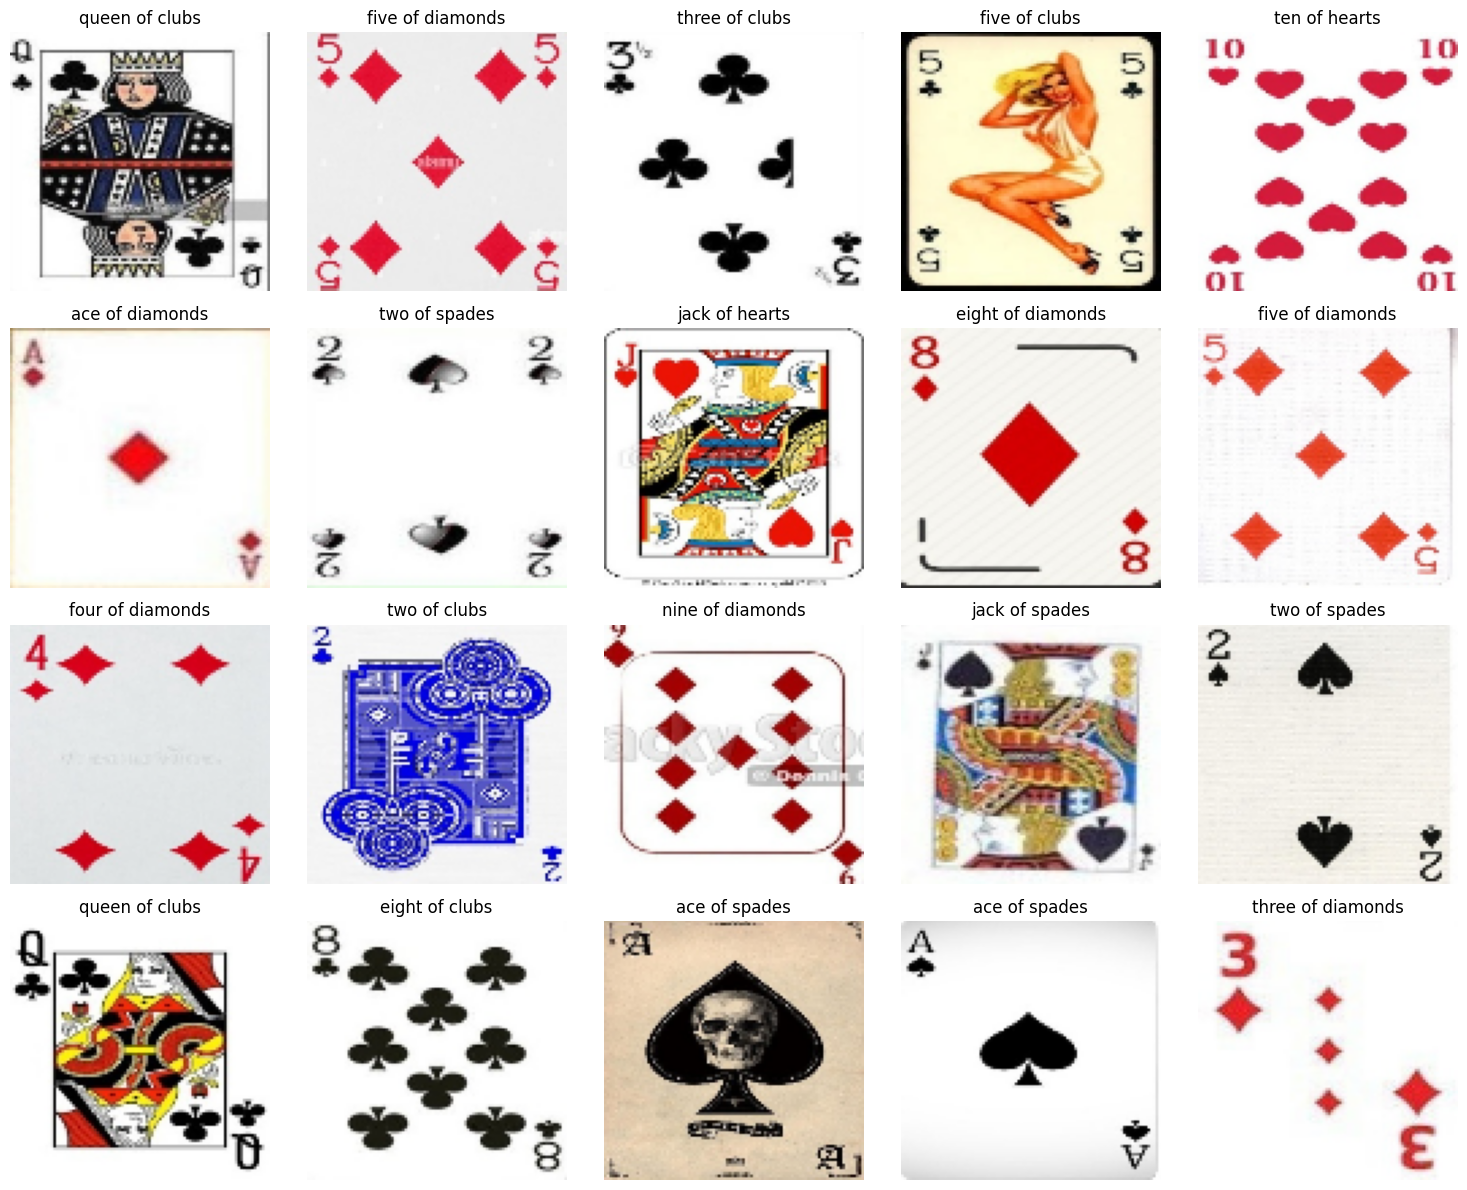

Visualization completed!


In [9]:
print('='*50)
print("Part B - TASK 3: Visualization")
print('-'*50)
print("Displaying 20 random samples from X_train")
print('='*50)

idx_to_class = {idx: name for name, idx in class_to_idx.items()}

#Randomly pick 20 samples from X_train
random_index = random.sample(range(len(X_train)), 20)


plt.figure(figsize=(15,12))

for i, idx in enumerate(random_index):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(idx_to_class[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Visualization completed!")

## **Task 4: Normalization and Splits**

In [10]:
print('='*50)
print("Part B - TASK 4: Normalization & Reshaping")
print('='*50)
print()
print('='*50)
print(f"Before Normalization -- Pixel Range: {X_train.min()} to {X_train.max()}")
print()

X_train_norm_b = X_train / 255
X_val_norm_b = X_val / 255
X_test_norm_b = X_test / 255

print(f"After Normalization -- Pixel Range: {X_train_norm_b.min():.1f} to {X_train_norm_b.max():.1f}")
print('='*50)
print()

print('='*50)
print("Reshape to 4D Tensor")
print('='*50)
print()

X_train_tensor = X_train_norm_b.reshape(-1, 96, 96, 3)
X_val_tensor = X_val_norm_b.reshape(-1, 96, 96, 3)
X_test_tensor = X_test_norm_b.reshape(-1, 96, 96, 3)

print("Normalization & Reshaping to 4D Tensor completed!")

Part B - TASK 4: Normalization & Reshaping

Before Normalization -- Pixel Range: 0 to 255

After Normalization -- Pixel Range: 0.0 to 1.0

Reshape to 4D Tensor

Normalization & Reshaping to 4D Tensor completed!


## **Task 5: CNN Modeling**

In [11]:
print('='*50)
print("Part B - TASK 5: CNN Modeling Architecture")
print('='*50)
print()

num_class = 53

cnn_model = Sequential([
       Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding='same', activation='relu', input_shape=(96, 96, 3)),
       BatchNormalization(),
       MaxPooling2D(2, 2),
       Dropout(0.25),

       Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
       BatchNormalization(),
       MaxPooling2D(2, 2),
       Dropout(0.25),
       
       Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
       BatchNormalization(),
       Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
       BatchNormalization(),
       MaxPooling2D(2,2),
       Dropout(0.4),

       GlobalAveragePooling2D(),
       Dense(256, activation='relu'),
       Dropout(0.5),
       Dense(num_class, activation='softmax')
])

cnn_model.summary()

print("CNN Model created!")

Part B - TASK 5: CNN Modeling Architecture



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 96, 96, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 96, 96, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 48, 48, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 48, 48, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        18496     
                                                                 
 batch_nor

In [12]:
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("CNN Model compiled & ready for training")

history = cnn_model.fit(X_train_tensor, y_train, epochs=16, validation_data=(X_val_tensor, y_val), verbose=1)

print("Training Completed!")


CNN Model compiled & ready for training
Epoch 1/16


239/239 [==============================] - 89s 360ms/step - loss: 3.5271 - accuracy: 0.0778 - val_loss: 5.9706 - val_accuracy: 0.0151
Epoch 2/16
239/239 [==============================] - 79s 330ms/step - loss: 3.0513 - accuracy: 0.1271 - val_loss: 3.9778 - val_accuracy: 0.0755
Epoch 3/16
239/239 [==============================] - 80s 334ms/step - loss: 2.7573 - accuracy: 0.1836 - val_loss: 3.3812 - val_accuracy: 0.0792
Epoch 4/16
239/239 [==============================] - 79s 332ms/step - loss: 2.5005 - accuracy: 0.2356 - val_loss: 2.8430 - val_accuracy: 0.2000
Epoch 5/16
239/239 [==============================] - 82s 343ms/step - loss: 2.2606 - accuracy: 0.2947 - val_loss: 1.9578 - val_accuracy: 0.3472
Epoch 6/16
239/239 [==============================] - 80s 333ms/step - loss: 2.0272 - accuracy: 0.3573 - val_loss: 1.4652 - val_accuracy: 0.5019
Epoch 7/16
239/239 [==============================] - 77s 321ms/step - loss: 1.7892 - a

## **Task 7: Evaluation**

Part B - TASK 7: Loss Curves


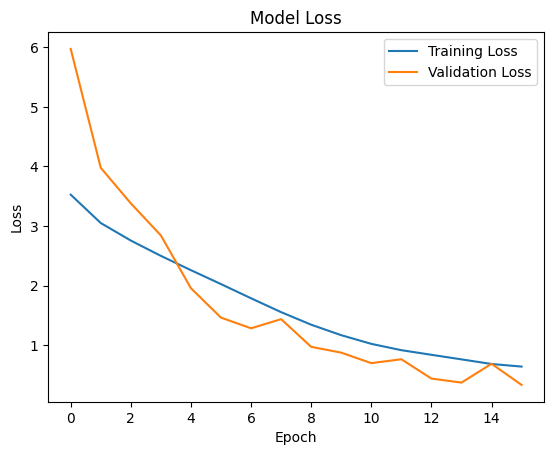

In [13]:
print('='*50)
print("Part B - TASK 7: Loss Curves")
print('='*50)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Part B - TASK 7: Accuracy Curves


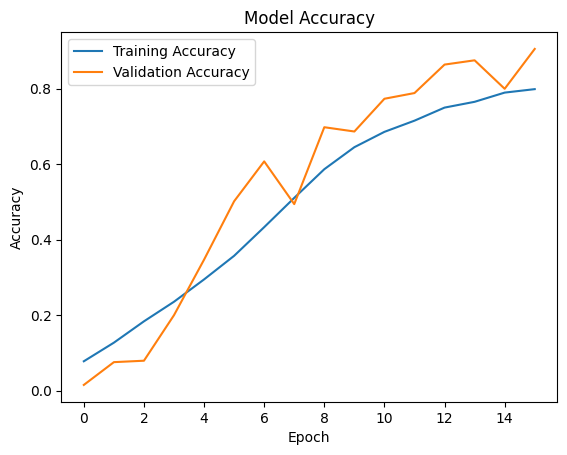

In [14]:
print('='*50)
print("Part B - TASK 7: Accuracy Curves")
print('='*50)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
print('='*50)
print("Part B - TASK 7: Prediction")
print('='*50)
print()

y_pred = cnn_model.predict(X_test_tensor).argmax(axis=1)

print(f"Converted Labels: {y_pred[:5]}")

Part B - TASK 7: Prediction

9/9 [==============================] - 1s 54ms/step
Converted Labels: [0 0 3 0 0]


In [16]:
print('='*50)
print("Part B - TASK 7: Classification Report")
print('='*50)
print()

print(classification_report(y_true=y_test, y_pred=y_pred))

print("Classification Report completed!")
print("Evaluation completed!")

Part B - TASK 7: Classification Report

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       1.00      0.80      0.89         5
           2       0.83      1.00      0.91         5
           3       0.71      1.00      0.83         5
           4       0.56      1.00      0.71         5
           5       0.38      1.00      0.56         5
           6       0.56      1.00      0.71         5
           7       1.00      0.60      0.75         5
           8       0.57      0.80      0.67         5
           9       0.80      0.80      0.80         5
          10       1.00      0.80      0.89         5
          11       0.71      1.00      0.83         5
          12       1.00      1.00      1.00         5
          13       1.00      0.80      0.89         5
          14       1.00      0.80      0.89         5
          15       1.00      0.80      0.89         5
          16       1.00      0.80      0.